In [2]:
import statsmodels.api as sm
import gpboost as gpb
import numpy as np
import matplotlib.pyplot as plt
import engression
import torch
import time
import pandas as pd
import gpytorch as gpy
from engression import engression
plt.style.use('ggplot')
from lagp.utils.gpytorch_utils import GPRegressionModel, AsymmetricLaplaceLikelihood, AsymmetricLaplaceLikelihood_DKLGP
import viva
import copy
from viva import VIVACpp as VIVA, my_train_cpp as my_train

In [3]:
# load qgam results
qgam = pd.read_csv("../results/realdata/qgam_acceleration.csv")

In [4]:
pred_qgam = qgam["fit"]
print(pred_qgam.shape)

(1000,)


In [5]:
X_pred = qgam["times"]

In [ ]:
# Load the dataset
mcycle = sm.datasets.get_rdataset("mcycle", "MASS")
df = mcycle.data
N = len(df)
# Check it out
print(df.shape)
X = df["times"]
y = df["accel"]

(133, 2)


In [8]:
delta_logl = 1
q = 0.8
likelihood = "asymmetric_laplace_constant_curvature_fisher_mode_finding" #
gpq = gpb.GPModel(gp_coords  = X ,
                    cov_function="matern",
                    cov_fct_shape= 1.5,
                    likelihood=likelihood, 
                    likelihood_additional_param = q, 
                    cover_tree_radius = delta_logl)
params = {"estimate_aux_pars": True, "init_aux_pars" : np.array([1]), "trace":False}
gpq.fit(X = np.ones(N), y=y, params = params) 

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 1
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 13.0565, delta_log_like_up_ = 38.4087, delta_log_like_down_ = 421.689
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 16.6419, delta_log_like_up_ = 20.5213, delta_log_like_down_ = 211.371
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 11.8187, delta_log_like_up_ = 1.00049, delta_log_like_down_ = 82.7621
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 12.4024, delta_log_like_up_ = 1.00014, delta_log_like_down_ = 53.1211
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_mode_ = 12.8221, delta_log_like_up_ = 1.00039, delta_log_like_down_ = 41.212
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_mode_ = 13.0375, delta_log_like_up_ = 1.00021, delta_log_like_down_ = 36.5434
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_

In [9]:
pred_gpb = gpq.predict(X_pred = np.ones(len(X_pred)), 
                   gp_coords_pred = X_pred, predict_response=False, 
                   predict_var=True) # get the latent

[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 21, delta_mode_ = 2.84089, delta_log_like_up_ = 6.59462, delta_log_like_down_ = 7.54709


In [10]:
gpq.get_coef()

,Covariate_1
Param.,6.188419


In [11]:
gpq.get_aux_pars()["scale"]

Param.    4.158118
Name: scale, dtype: float64

In [12]:
gpq.get_cov_pars()

,GP_var,GP_range
Param.,786.540347,10.048639


In [13]:
# Assuming train_X, train_y, test_X, test_y are numpy arrays
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
X_pred_tensor = torch.tensor(X_pred, dtype=torch.float32)

likelihood = AsymmetricLaplaceLikelihood(quantile=q)
model = GPRegressionModel(X_tensor, 1000, 500)  # Instantiate the GPyTorch model
K = model(X_tensor).covariance_matrix.clone()
kernel_frozen = copy.deepcopy(model.covar_module)

In [14]:

# ---- Training ----
model.train()
likelihood.train()

optimizer = torch.optim.Adam(
                        [
                        {"params": model.parameters()},
                        {"params": likelihood.parameters()},
                        ],
                        lr=0.1,
                        )

mll = gpy.mlls.VariationalELBO(likelihood, model, num_data=y_tensor.size(0))

num_epochs = 500
start_time = time.time()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = -mll(output, y_tensor)
    loss.backward()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
    optimizer.step()
    end_time = time.time()
    elapsed_time = end_time - start_time

# ---- Evaluation ----
model.eval()
likelihood.eval()
with torch.no_grad():
    pred = model(X_pred_tensor)

c:\Users\JumpStart\Documents\environments\latest\Lib\site-packages\torch\distributions\distribution.py:56: UserWarning: <class 'lagp.utils.gpytorch_utils.AsymmetricLaplaceOutput'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


Epoch 0: Loss = 13.5037
Epoch 50: Loss = 6.1066
Epoch 100: Loss = 5.6911
Epoch 150: Loss = 5.5175
Epoch 200: Loss = 5.4256
Epoch 250: Loss = 5.3488
Epoch 300: Loss = 5.3001
Epoch 350: Loss = 5.2876
Epoch 400: Loss = 5.2512
Epoch 450: Loss = 5.2252


In [15]:
pred_gpy = pred.mean

In [16]:
X_tensor.size()

torch.Size([133])

In [17]:
kernel_frozen.base_kernel.lengthscale

tensor([[0.6931]], grad_fn=<SoftplusBackward0>)

In [18]:
X_tensor.unsqueeze(-1).shape

torch.Size([133, 1])

In [19]:
y_tensor.shape

torch.Size([133])

In [20]:
kernel_frozen.base_kernel.lengthscale = kernel_frozen.base_kernel.lengthscale

In [21]:
kernel_frozen.base_kernel.lengthscale

tensor([[0.6931]], grad_fn=<SoftplusBackward0>)

In [22]:
likelihood = AsymmetricLaplaceLikelihood_DKLGP(quantile=q)

In [ ]:
rho = 2.0
n_test = 110
classify = False
X_tensor = X_tensor.unsqueeze(-1)
print(X_tensor.size())
model = VIVA(X_tensor, y_tensor, kernel_frozen, likelihood, rho, n_test=n_test,
                 classify=classify, use_ic0=False) # initialize from the laplace

torch.Size([133, 1])
tensor([[ 3.4625],
        [ 3.7510],
        [ 4.6166],
        [ 5.1937],
        [ 5.7708],
        [ 8.9447],
        [ 9.5218],
        [ 9.8103],
        [11.2530],
        [11.8301],
        [12.6957],
        [12.6957],
        [13.8499],
        [14.4270],
        [14.7155],
        [15.2926],
        [15.8696],
        [16.4467],
        [19.0436],
        [19.6207],
        [19.9092],
        [21.0633],
        [21.0633],
        [21.0633],
        [21.0633],
        [21.0633],
        [21.0633],
        [21.3519],
        [22.2175],
        [22.2175],
        [22.2175],
        [22.2175],
        [22.5060],
        [22.5060],
        [22.7946],
        [22.7946],
        [23.0831],
        [23.0831],
        [23.3717],
        [23.3717],
        [23.3717],
        [23.6602],
        [23.6602],
        [23.9487],
        [24.2373],
        [24.2373],
        [24.2373],
        [25.3914],
        [25.3914],
        [25.3914],
        [25.3914],
        [2

RuntimeError: select(): index 196983 out of range for tensor of size [133, 1] at dimension 0
Exception raised from select_symint at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:1851 (most recent call first):
00007FFD77EE91D900007FFD77EE9130 c10.dll!c10::Error::Error [<unknown file> @ <unknown line number>]
00007FFD77E9501500007FFD77E94FA0 c10.dll!c10::IndexError::IndexError [<unknown file> @ <unknown line number>]
00007FFCED4AB3C000007FFCED4AA8B0 torch_cpu.dll!at::native::select_symint [<unknown file> @ <unknown line number>]
00007FFCEE12403100007FFCEE11B5F0 torch_cpu.dll!at::compositeexplicitautograd::view_copy_symint_outf [<unknown file> @ <unknown line number>]
00007FFCEE0EF04000007FFCEE0A63B0 torch_cpu.dll!at::compositeexplicitautograd::bucketize_outf [<unknown file> @ <unknown line number>]
00007FFCEDCADCD200007FFCEDC5A1D0 torch_cpu.dll!at::_ops::vsplit_int::redispatch [<unknown file> @ <unknown line number>]
00007FFCEDD76FB200007FFCEDD76F00

In [ ]:
my_train(model, n_Epoch=100)

In [ ]:
mu_post, var_post = model.predict(X_pred)
sd_post = var_post.sqrt()
mu_post_VIVA = mu_post.detach().clone()
sd_post_VIVA = sd_post.detach().clone()

Text(0.5, 1.0, 'Quantile: 0.8')

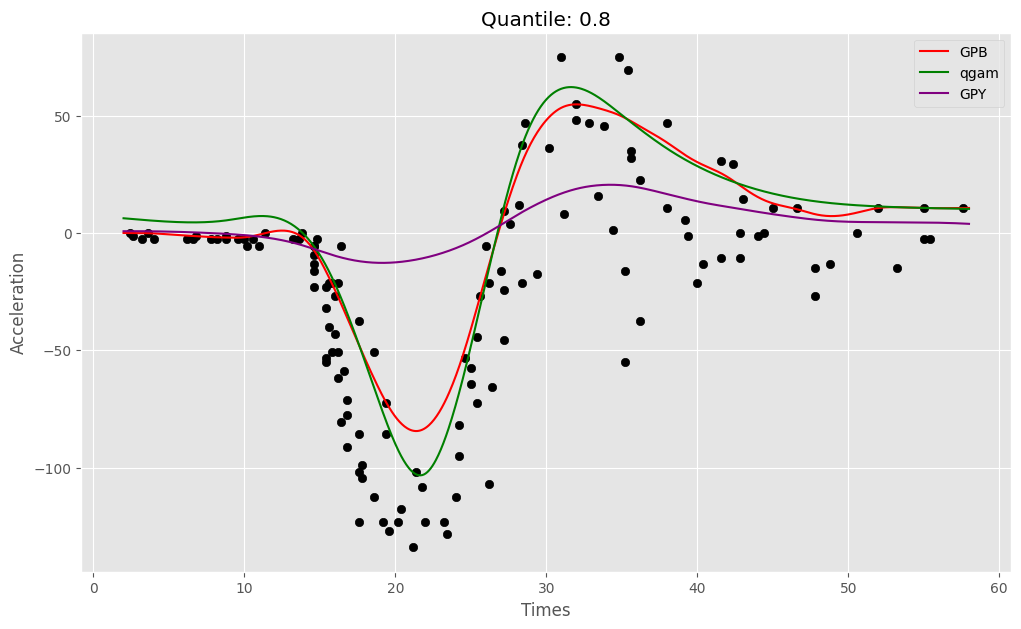

In [ ]:
y_pred =  pred_gpb["mu"]
var_pred = pred_gpb["var"]
lower = y_pred - 2*np.sqrt(var_pred)
upper = y_pred + 2*np.sqrt(var_pred)
plt.figure(figsize=(12,7))
plt.plot(X_pred, y_pred, color = "red", label = "GPB")
plt.plot(X_pred, pred_qgam, color = "green", label = "qgam")
plt.plot(X_pred, pred_gpy, color = "purple", label = "GPY")
# plt.fill_between(X_pred, y1 = lower, y2 = upper, color = "lightgreen", alpha = 0.5)
plt.scatter(X, y, color = "black")
plt.xlabel("Times")
plt.ylabel("Acceleration")
plt.legend(labelcolor = "black")
plt.title(f"Quantile: {q}", color = "black")